# Este pipeline se encarga de limpiar los datasets de training y testing

In [11]:
# IMPORTS
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.window import Window
import matplotlib.pyplot as plt
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.functions import vector_to_array

In [12]:
# Sesión Spark
spark = (
    SparkSession.builder
    .appName("TFM_CMAPPSS_FD001_Preprocesado")
    .getOrCreate()
)
spark.conf.set("spark.hadoop.mapreduce.fileoutputcommitter.algorithm.version", "2")
spark.conf.set("spark.hadoop.mapreduce.fileoutputcommitter.cleanup-failures.ignored", "true")

In [13]:
# Carga del fichero raw
train_url = "/opt/spark-data/raw/train_FD001.txt"
test_url = "/opt/spark-data/raw/test_FD001.txt"

df_train = spark.read \
    .option("sep", " ") \
    .option("inferSchema", "true") \
    .csv(train_url)
df_test = spark.read \
    .option("sep", " ") \
    .option("inferSchema", "true") \
    .csv(test_url)

In [14]:
# EDA inicial
print("Train dataset")
print("Numero de filas:",df_train.count())
print("Numero de columnas:", len(df_train.columns))
df_train.show()
df_train.printSchema()
print("Test dataset")
print("Numero de filas:",df_test.count())
print("Numero de columnas:", len(df_test.columns))
df_test.show()
df_test.printSchema()

Train dataset
Numero de filas: 20631
Numero de columnas: 28
+---+---+-------+-------+-----+------+------+-------+-------+-----+-----+------+-------+-------+----+-----+------+-------+-------+------+----+----+----+-----+-----+-------+----+----+
|_c0|_c1|    _c2|    _c3|  _c4|   _c5|   _c6|    _c7|    _c8|  _c9| _c10|  _c11|   _c12|   _c13|_c14| _c15|  _c16|   _c17|   _c18|  _c19|_c20|_c21|_c22| _c23| _c24|   _c25|_c26|_c27|
+---+---+-------+-------+-----+------+------+-------+-------+-----+-----+------+-------+-------+----+-----+------+-------+-------+------+----+----+----+-----+-----+-------+----+----+
|  1|  1|-7.0E-4|-4.0E-4|100.0|518.67|641.82| 1589.7| 1400.6|14.62|21.61|554.36|2388.06|9046.19| 1.3|47.47|521.66|2388.02|8138.62|8.4195|0.03| 392|2388|100.0|39.06| 23.419|NULL|NULL|
|  1|  2| 0.0019|-3.0E-4|100.0|518.67|642.15|1591.82|1403.14|14.62|21.61|553.75|2388.04|9044.07| 1.3|47.49|522.28|2388.07|8131.49|8.4318|0.03| 392|2388|100.0| 39.0|23.4236|NULL|NULL|
|  1|  3|-0.0043| 3.0E-4|

## Se puede comprobar que algunas columnas podrían ser nulas, así que eliminamos las que lo sean.

In [17]:
# Eliminamos columnas vacías
expr_notnull_train = [
    F.max(
        F.when(
            (F.col(c).isNotNull()) & (F.trim(F.col(c)) != ""),
            1
        ).otherwise(0)
    ).alias(c)
    for c in df_train.columns
]

expr_notnull_test = [
    F.max(
        F.when(
            (F.col(c).isNotNull()) & (F.trim(F.col(c)) != ""),
            1
        ).otherwise(0)
    ).alias(c)
    for c in df_test.columns
]

resultado_train = df_train.select(expr_notnull_train).collect()[0].asDict()
resultado_test = df_test.select(expr_notnull_test).collect()[0].asDict()

columnas_validas_train = [c for c, v in resultado_train.items() if v == 1]
columnas_validas_test = [c for c, v in resultado_test.items() if v == 1]

df_train_clean = df_train.select(columnas_validas_train)
df_test_clean = df_test.select(columnas_validas_test)

print("Numero de columnas en train después de limpieza de nulos:", len(df_train_clean.columns))
df_train_clean.show()

print("Numero de columnas en test después de limpieza de nulos:", len(df_test_clean.columns))
df_test_clean.show()

Numero de columnas en train después de limpieza de nulos: 26
+---+---+-------+-------+-----+------+------+-------+-------+-----+-----+------+-------+-------+----+-----+------+-------+-------+------+----+----+----+-----+-----+-------+
|_c0|_c1|    _c2|    _c3|  _c4|   _c5|   _c6|    _c7|    _c8|  _c9| _c10|  _c11|   _c12|   _c13|_c14| _c15|  _c16|   _c17|   _c18|  _c19|_c20|_c21|_c22| _c23| _c24|   _c25|
+---+---+-------+-------+-----+------+------+-------+-------+-----+-----+------+-------+-------+----+-----+------+-------+-------+------+----+----+----+-----+-----+-------+
|  1|  1|-7.0E-4|-4.0E-4|100.0|518.67|641.82| 1589.7| 1400.6|14.62|21.61|554.36|2388.06|9046.19| 1.3|47.47|521.66|2388.02|8138.62|8.4195|0.03| 392|2388|100.0|39.06| 23.419|
|  1|  2| 0.0019|-3.0E-4|100.0|518.67|642.15|1591.82|1403.14|14.62|21.61|553.75|2388.04|9044.07| 1.3|47.49|522.28|2388.07|8131.49|8.4318|0.03| 392|2388|100.0| 39.0|23.4236|
|  1|  3|-0.0043| 3.0E-4|100.0|518.67|642.35|1587.99| 1404.2|14.62|21.61|5

**Se han eliminado _c26 y _c27 en ambos dataframes**

In [18]:
# Renombrar columnas
columnas = {
    "_c0": "unit_number",
    "_c1": "time_in_cycles",
    "_c2": "setting_1",
    "_c3": "setting_2",
    "_c4": "setting_3",
    **{f"_c{i}": f"sensor_{i-4}" for i in range(5, 26)}
}
    
for antigua, nueva in columnas.items():
    df_train_clean = df_train_clean.withColumnRenamed(antigua, nueva)
    df_test_clean = df_test_clean.withColumnRenamed(antigua, nueva)

In [20]:
print("Columnas train:",df_train_clean.columns)
print("Columnas test:",df_test_clean.columns)

Columnas train: ['unit_number', 'time_in_cycles', 'setting_1', 'setting_2', 'setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']
Columnas test: ['unit_number', 'time_in_cycles', 'setting_1', 'setting_2', 'setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


## Compruebo que no hay filas duplicadas

In [21]:
# Comprobar duplicados
print("Duplicados en train:")
dups = (
    df_train_clean.groupBy("unit_number", "time_in_cycles")
      .count()
      .filter(F.col("count") > 1)
)

dups.show()
print("Duplicados en test:")
dups = (
    df_test_clean.groupBy("unit_number", "time_in_cycles")
      .count()
      .filter(F.col("count") > 1)
)

dups.show()

Duplicados en train:
+-----------+--------------+-----+
|unit_number|time_in_cycles|count|
+-----------+--------------+-----+
+-----------+--------------+-----+

Duplicados en test:
+-----------+--------------+-----+
|unit_number|time_in_cycles|count|
+-----------+--------------+-----+
+-----------+--------------+-----+



**No hay registros duplicados**

In [23]:
print("-"*300)
print("VALORES ÚNICOS POR COLUMNA (TRAIN)")
print("-"*300)

df_unicos_train = df_train_clean.select([
    F.countDistinct(c).alias(c)
    for c in df_train_clean.columns
])

df_unicos_train.show()

print("-"*300)
print("VALORES ÚNICOS POR COLUMNA (TEST)")
print("-"*300)

df_unicos_test = df_test_clean.select([
    F.countDistinct(c).alias(c)
    for c in df_test_clean.columns
])

df_unicos_test.show()

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
VALORES ÚNICOS POR COLUMNA (TRAIN)
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
+-----------+--------------+---------+---------+---------+--------+--------+--------+--------+--------+--------+--------+--------+--------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+
|unit_number|time_in_cycles|setting_1|setting_2|setting_3|sensor_1|sensor_2|sensor_3|sensor_4|sensor_5|

**Podemos ver que existen variables constantes, que no aportan información para Machine Learning, con lo cual vamos a eliminarlas también.**

In [24]:
print("Limpiando train...")
fila = df_unicos_train.collect()[0].asDict()

for c, valor in fila.items():
    if valor == 1:
        print("Eliminando",c)
        df_train_clean = df_train_clean.drop(c)
df_train_clean2 = df_train_clean
print("Limpiando test...")
fila = df_unicos_test.collect()[0].asDict()

for c, valor in fila.items():
    if valor == 1:
        print("Eliminando",c)
        df_test_clean = df_test_clean.drop(c)
df_test_clean2 = df_test_clean

Limpiando train...
Eliminando setting_3
Eliminando sensor_1
Eliminando sensor_5
Eliminando sensor_10
Eliminando sensor_16
Eliminando sensor_18
Eliminando sensor_19
Limpiando test...
Eliminando setting_3
Eliminando sensor_1
Eliminando sensor_5
Eliminando sensor_10
Eliminando sensor_16
Eliminando sensor_18
Eliminando sensor_19


In [25]:
df_train_clean2.show()
print("Columnas en train trás limpieza:",len(df_train_clean2.columns))
df_test_clean2.show()
print("Columnas test trás limpieza:",len(df_test_clean2.columns))

+-----------+--------------+---------+---------+--------+--------+--------+--------+--------+--------+--------+---------+---------+---------+---------+---------+---------+---------+---------+
|unit_number|time_in_cycles|setting_1|setting_2|sensor_2|sensor_3|sensor_4|sensor_6|sensor_7|sensor_8|sensor_9|sensor_11|sensor_12|sensor_13|sensor_14|sensor_15|sensor_17|sensor_20|sensor_21|
+-----------+--------------+---------+---------+--------+--------+--------+--------+--------+--------+--------+---------+---------+---------+---------+---------+---------+---------+---------+
|          1|             1|  -7.0E-4|  -4.0E-4|  641.82|  1589.7|  1400.6|   21.61|  554.36| 2388.06| 9046.19|    47.47|   521.66|  2388.02|  8138.62|   8.4195|      392|    39.06|   23.419|
|          1|             2|   0.0019|  -3.0E-4|  642.15| 1591.82| 1403.14|   21.61|  553.75| 2388.04| 9044.07|    47.49|   522.28|  2388.07|  8131.49|   8.4318|      392|     39.0|  23.4236|
|          1|             3|  -0.0043|  

In [26]:
print("-"*300)
print("DISTRIBUCIÓN POR COLUMNA (TRAIN)")
print("-"*300)

for c in df_train_clean2.columns:
    print(f"\n===== {c} =====")

    df_train_clean2.select(
        F.count(c).alias("count"),
        F.mean(c).alias("mean"),
        F.stddev(c).alias("std"),
        F.min(c).alias("min"),
        F.max(c).alias("max")
    ).show()

print("-"*300)
print("DISTRIBUCIÓN POR COLUMNA (TEST)")
print("-"*300)

for c in df_test_clean2.columns:
    print(f"\n===== {c} =====")

    df_test_clean2.select(
        F.count(c).alias("count"),
        F.mean(c).alias("mean"),
        F.stddev(c).alias("std"),
        F.min(c).alias("min"),
        F.max(c).alias("max")
    ).show()

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
DISTRIBUCIÓN POR COLUMNA (TRAIN)
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

===== unit_number =====
+-----+------------------+-----------------+---+---+
|count|              mean|              std|min|max|
+-----+------------------+-----------------+---+---+
|20631|51.506567786340945|29.22763290879931|  1|100|
+-----+------------------+-----------------+---+---+


===== time_in_cycles =====
+-----+------------------+-----------------+--

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
HISTOGRAMAS (TRAIN)
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


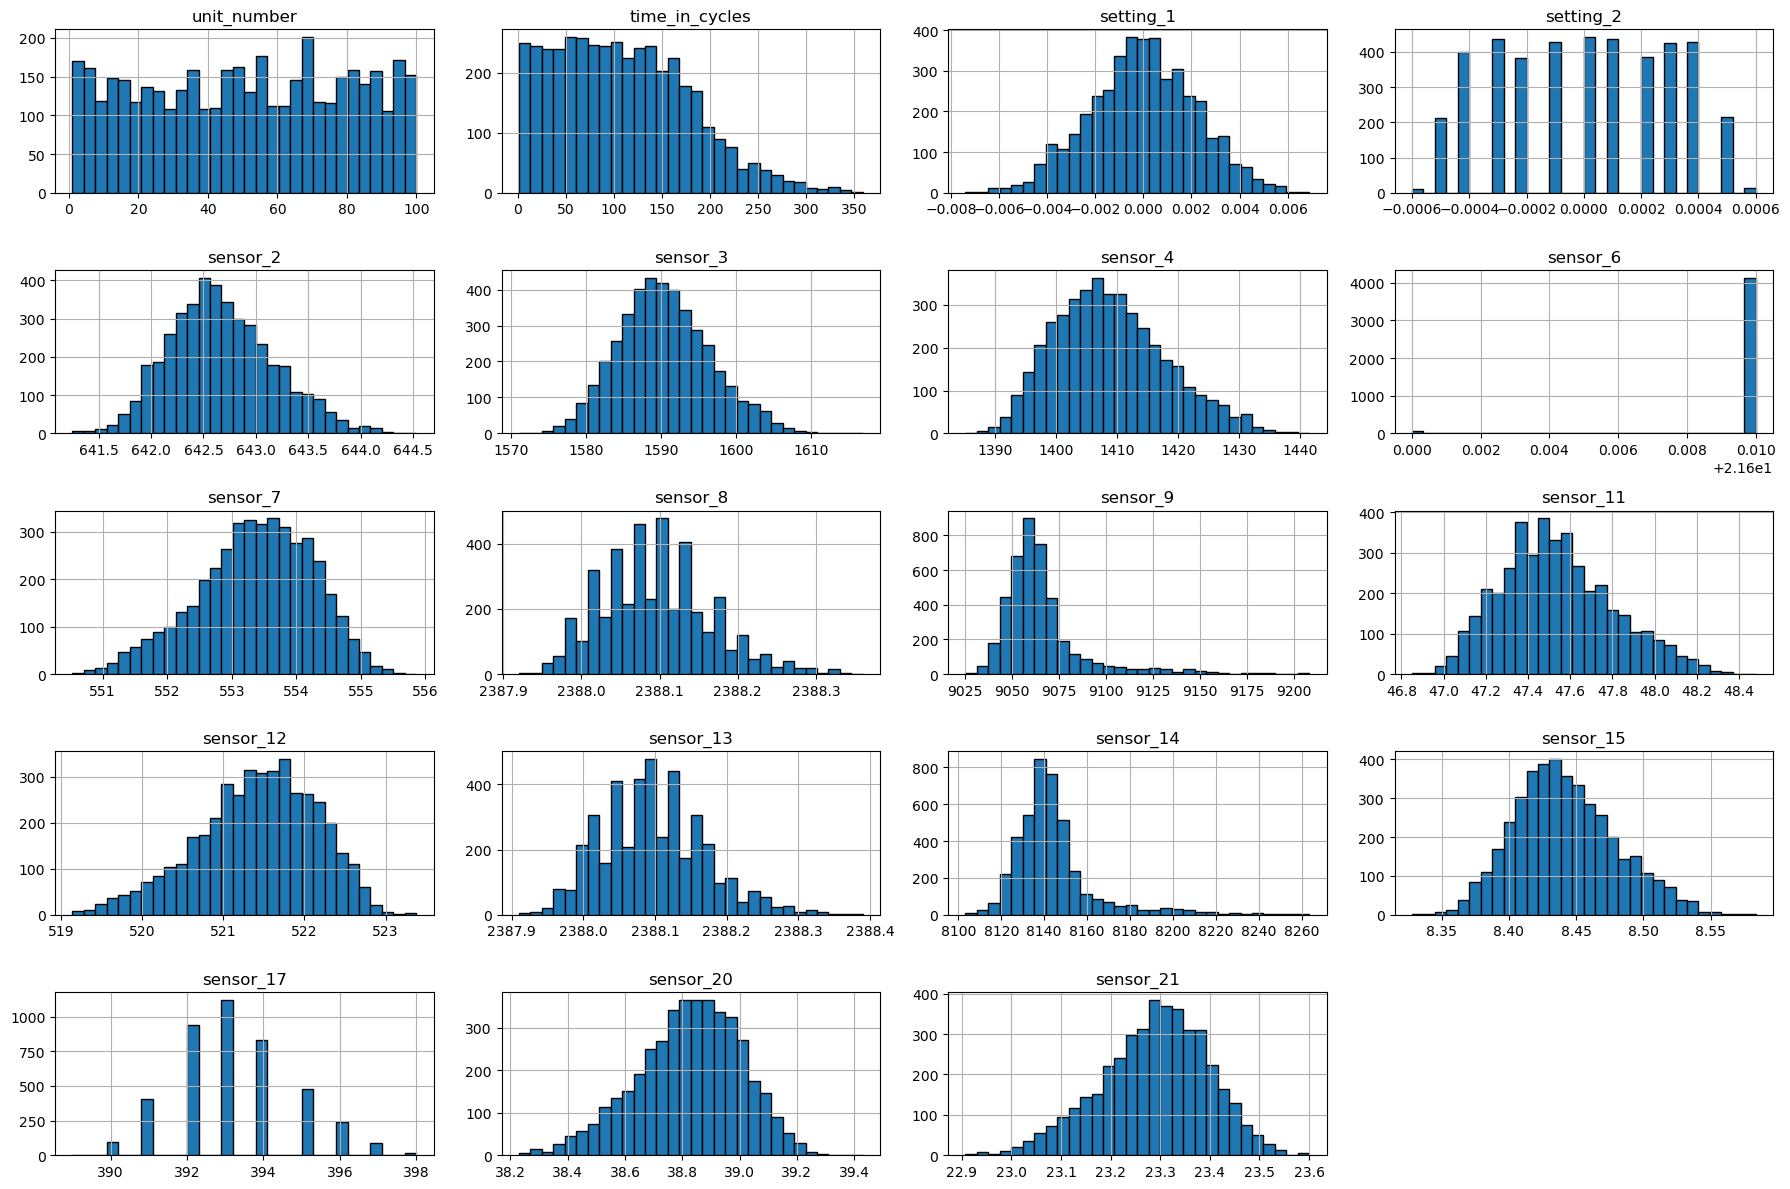

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
HISTOGRAMAS (TEST)
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


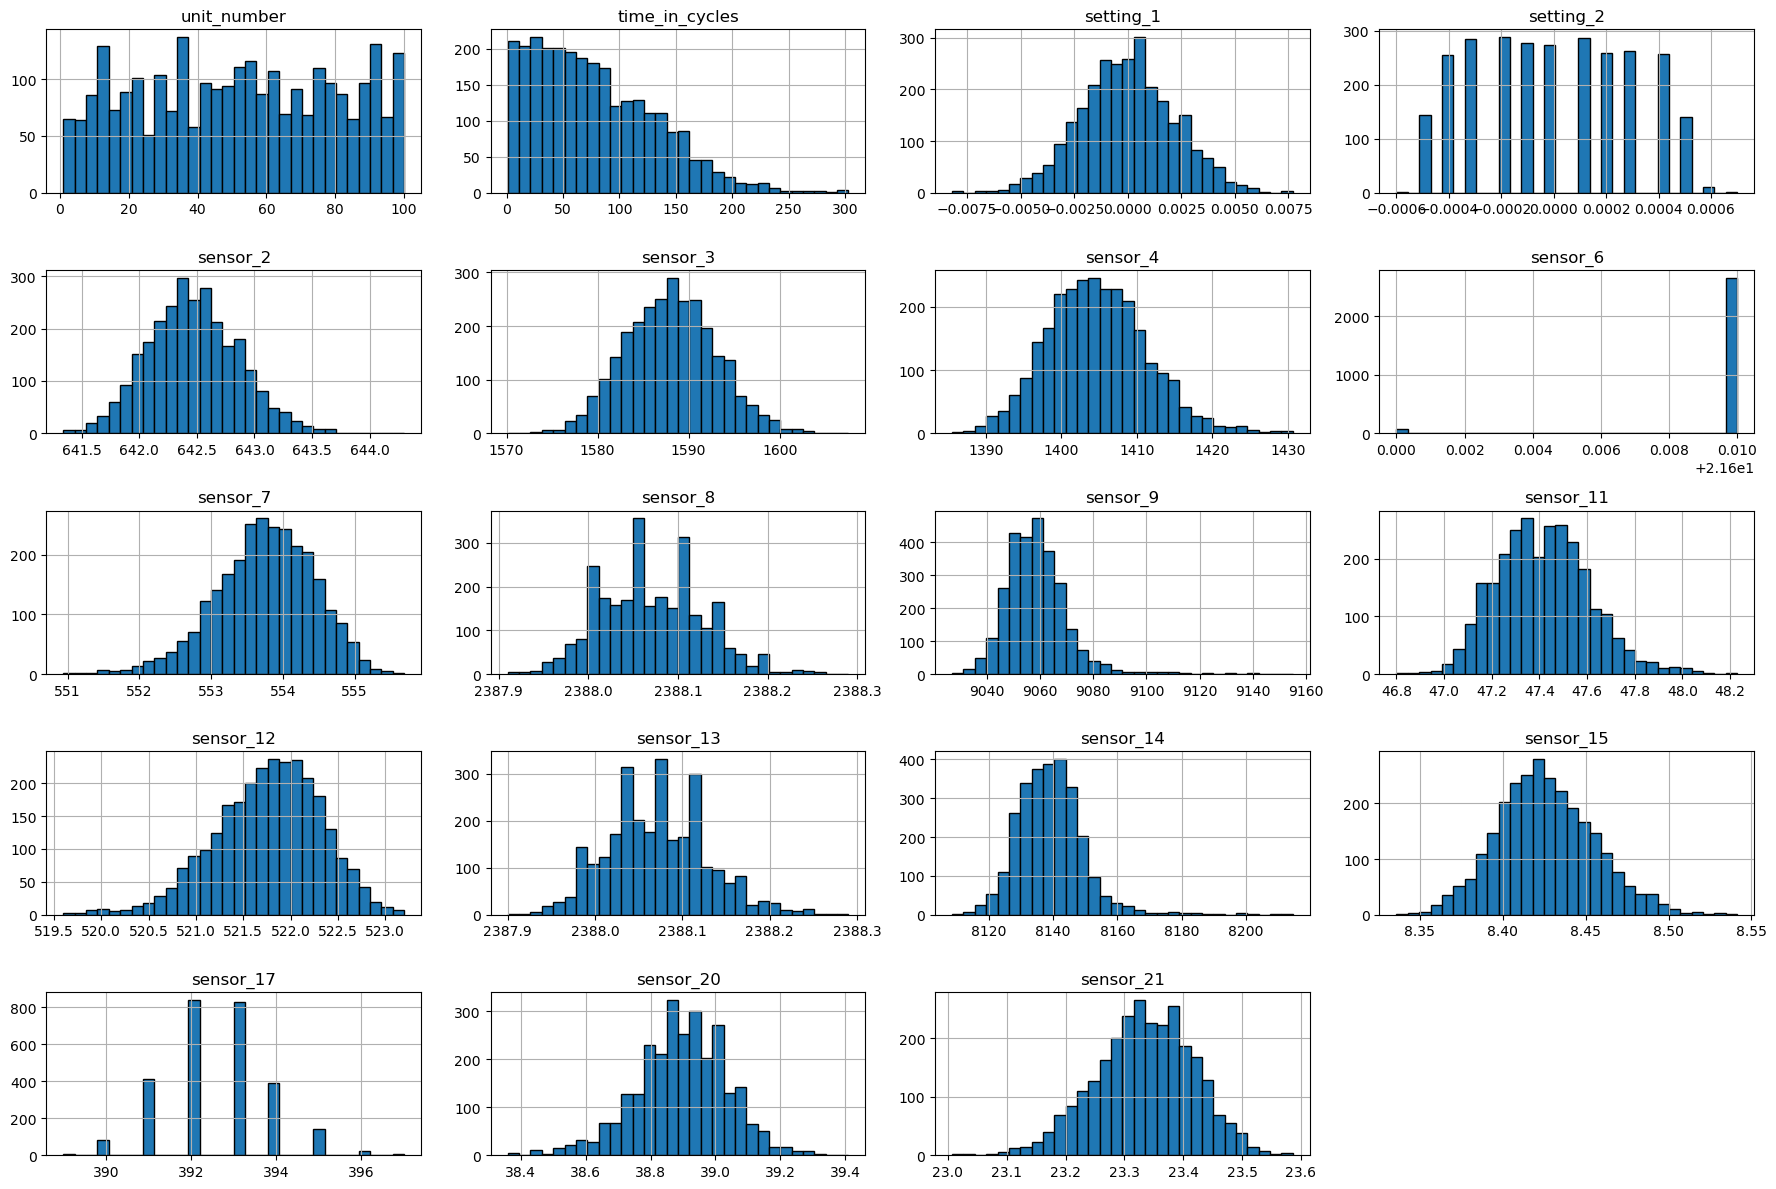

In [27]:
# HISTOGRAMAS
print("-"*300)
print("HISTOGRAMAS (TRAIN)")
print("-"*300)
hdf = df_train_clean2.sample(False, 0.2, seed=42).toPandas()

hdf.hist(
    bins=30,
    figsize=(18, 12),
    edgecolor="black"
)

plt.tight_layout()
plt.show()
print("-"*300)
print("HISTOGRAMAS (TEST)")
print("-"*300)
hdf = df_test_clean2.sample(False, 0.2, seed=42).toPandas()

hdf.hist(
    bins=30,
    figsize=(18, 12),
    edgecolor="black"
)

plt.tight_layout()
plt.show()

1. **El sensor 6 tiene 2 valores que en realidad son el mismo con variación centimal. Con lo que lo eliminamos, igual que hicimos con las variables constantes.**
2. **En datasets industriales orientados a mantenimiento predictivo, los valores extremos no siempre representan ruido. Muchos corresponden a estados avanzados de degradación de la maquinaria y contienen información relevante para la predicción del fallo. Por ello, no aplicamos una eliminación agresiva de outliers.**

In [28]:
print("-"*300)
print("Eliminando sensor 6 de train")
print("-"*300)
df_train_clean3 = df_train_clean2.drop("sensor_6")
df_train_clean3.show()
print("-"*300)
print("Eliminando sensor 6 de test")
print("-"*300)
df_test_clean3 = df_test_clean2.drop("sensor_6")
df_test_clean3.show()

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Eliminando sensor 6 de train
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
+-----------+--------------+---------+---------+--------+--------+--------+--------+--------+--------+---------+---------+---------+---------+---------+---------+---------+---------+
|unit_number|time_in_cycles|setting_1|setting_2|sensor_2|sensor_3|sensor_4|sensor_7|sensor_8|sensor_9|sensor_11|sensor_12|sensor_13|sensor_14|sensor_15|sensor_17|sensor_20|sensor_21|
+--

## Usamos Standard Scaler para estandarizar las variables para que todas tengan una media = 0 y una desviación estandar = 1

In [30]:
# Escalado de variables
columnas_no_features = [
    "unit_number",
    "time_in_cycles",
    "time_in_cycles",
    "features_raw",
    "features_scaled",
    "features_scaled_array"
]

print("Escalando dataset train...")

features = [
    c for c, t in df_train_clean3.dtypes
    if c not in columnas_no_features
    and t in ["int", "bigint", "float", "double"]
]

stds = df_train_clean3.select([
    F.stddev_samp(c).alias(c)
    for c in features
]).collect()[0].asDict()

features = [
    c for c in features
    if stds[c] is not None and stds[c] != 0
]

assembler = VectorAssembler(
    inputCols=features,
    outputCol="features_raw"
)

df_train_vec = assembler.transform(df_train_clean3)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features_scaled",
    withMean=True,
    withStd=True
)

scaler_model = scaler.fit(df_train_vec)
df_train_scaled = scaler_model.transform(df_train_vec)

df_train_scaled = df_train_scaled.withColumn(
    "features_scaled_array",
    vector_to_array("features_scaled")
)

for i, c in enumerate(features):
    df_train_scaled = df_train_scaled.withColumn(
        f"{c}_scaled",
        F.col("features_scaled_array")[i]
    )
# Comprobación
df_train_scaled.select([
    F.round(F.mean(f"{c}_scaled"), 6).alias(f"{c}_mean")
    for c in features
]).show(truncate=False)

df_train_scaled.select([
    F.round(F.stddev_samp(f"{c}_scaled"), 6).alias(f"{c}_std")
    for c in features
]).show(truncate=False)

print("Escalando dataset test...")

features = [
    c for c, t in df_test_clean3.dtypes
    if c not in columnas_no_features
    and t in ["int", "bigint", "float", "double"]
]

stds = df_test_clean3.select([
    F.stddev_samp(c).alias(c)
    for c in features
]).collect()[0].asDict()

features = [
    c for c in features
    if stds[c] is not None and stds[c] != 0
]

assembler = VectorAssembler(
    inputCols=features,
    outputCol="features_raw"
)

df_test_vec = assembler.transform(df_test_clean3)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features_scaled",
    withMean=True,
    withStd=True
)

scaler_model = scaler.fit(df_test_vec)
df_test_scaled = scaler_model.transform(df_test_vec)

df_test_scaled = df_test_scaled.withColumn(
    "features_scaled_array",
    vector_to_array("features_scaled")
)

for i, c in enumerate(features):
    df_test_scaled = df_test_scaled.withColumn(
        f"{c}_scaled",
        F.col("features_scaled_array")[i]
    )
# Comprobación
df_test_scaled.select([
    F.round(F.mean(f"{c}_scaled"), 6).alias(f"{c}_mean")
    for c in features
]).show(truncate=False)

df_test_scaled.select([
    F.round(F.stddev_samp(f"{c}_scaled"), 6).alias(f"{c}_std")
    for c in features
]).show(truncate=False)

Escalando dataset train...
+--------------+--------------+-------------+-------------+-------------+-------------+-------------+-------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+
|setting_1_mean|setting_2_mean|sensor_2_mean|sensor_3_mean|sensor_4_mean|sensor_7_mean|sensor_8_mean|sensor_9_mean|sensor_11_mean|sensor_12_mean|sensor_13_mean|sensor_14_mean|sensor_15_mean|sensor_17_mean|sensor_20_mean|sensor_21_mean|
+--------------+--------------+-------------+-------------+-------------+-------------+-------------+-------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+
|0.0           |0.0           |0.0          |0.0          |0.0          |0.0          |0.0          |0.0          |0.0           |0.0           |0.0           |0.0           |0.0           |0.0           |0.0           |0.0           |
+--------------+-------------

## Finalmente exporto los resultados a csv

In [32]:
# Selección de dataframes final
df_train_final = df_train_scaled.select(["unit_number", "time_in_cycles"] + [c for c in df_train_scaled.columns if ("_scaled" in c) and ("features" not in c)])
print("Columnas:",df_train_final.columns, "\nFilas:",df_train_final.count())
df_test_final = df_test_scaled.select(["unit_number", "time_in_cycles"] + [c for c in df_test_scaled.columns if ("_scaled" in c) and ("features" not in c)])
print("Columnas:",df_test_final.columns, "\nFilas:",df_test_final.count())

Columnas: ['unit_number', 'time_in_cycles', 'setting_1_scaled', 'setting_2_scaled', 'sensor_2_scaled', 'sensor_3_scaled', 'sensor_4_scaled', 'sensor_7_scaled', 'sensor_8_scaled', 'sensor_9_scaled', 'sensor_11_scaled', 'sensor_12_scaled', 'sensor_13_scaled', 'sensor_14_scaled', 'sensor_15_scaled', 'sensor_17_scaled', 'sensor_20_scaled', 'sensor_21_scaled'] 
Filas: 20631
Columnas: ['unit_number', 'time_in_cycles', 'setting_1_scaled', 'setting_2_scaled', 'sensor_2_scaled', 'sensor_3_scaled', 'sensor_4_scaled', 'sensor_7_scaled', 'sensor_8_scaled', 'sensor_9_scaled', 'sensor_11_scaled', 'sensor_12_scaled', 'sensor_13_scaled', 'sensor_14_scaled', 'sensor_15_scaled', 'sensor_17_scaled', 'sensor_20_scaled', 'sensor_21_scaled'] 
Filas: 13096


In [33]:
df_train_final.write \
    .mode("overwrite") \
    .option("header", "true") \
    .csv("/opt/spark-data/interim/TRAIN_FD001_CLEAN")

Py4JJavaError: An error occurred while calling o4073.csv.
: java.io.IOException: Failed to rename DeprecatedRawLocalFileStatus{path=file:/opt/spark-data/processed/train_FD001_clean/_temporary/0/task_202605161617152258594647920692961_0250_m_000000/part-00000-337959a0-26d6-4642-8de4-62b46ba4be38-c000.csv; isDirectory=false; length=6615638; replication=1; blocksize=33554432; modification_time=1778948236059; access_time=1778948236059; owner=; group=; permission=rw-rw-rw-; isSymlink=false; hasAcl=false; isEncrypted=false; isErasureCoded=false} to file:/opt/spark-data/processed/train_FD001_clean/part-00000-337959a0-26d6-4642-8de4-62b46ba4be38-c000.csv
	at org.apache.hadoop.mapreduce.lib.output.FileOutputCommitter.mergePaths(FileOutputCommitter.java:477)
	at org.apache.hadoop.mapreduce.lib.output.FileOutputCommitter.mergePaths(FileOutputCommitter.java:490)
	at org.apache.hadoop.mapreduce.lib.output.FileOutputCommitter.commitJobInternal(FileOutputCommitter.java:405)
	at org.apache.hadoop.mapre

In [34]:
df_test_final.write \
    .mode("overwrite") \
    .option("header", "true") \
    .csv("/opt/spark-data/interim/TEST_FD001_CLEAN")

Py4JJavaError: An error occurred while calling o4077.csv.
: java.io.IOException: Failed to rename DeprecatedRawLocalFileStatus{path=file:/opt/spark-data/processed/test_FD001_clean/_temporary/0/task_202605161617213866046516885324856_0251_m_000000/part-00000-a7c3186b-41a9-4fb5-aa65-ca4006e908a6-c000.csv; isDirectory=false; length=4192761; replication=1; blocksize=33554432; modification_time=1778948241932; access_time=1778948241932; owner=; group=; permission=rw-rw-rw-; isSymlink=false; hasAcl=false; isEncrypted=false; isErasureCoded=false} to file:/opt/spark-data/processed/test_FD001_clean/part-00000-a7c3186b-41a9-4fb5-aa65-ca4006e908a6-c000.csv
	at org.apache.hadoop.mapreduce.lib.output.FileOutputCommitter.mergePaths(FileOutputCommitter.java:477)
	at org.apache.hadoop.mapreduce.lib.output.FileOutputCommitter.mergePaths(FileOutputCommitter.java:490)
	at org.apache.hadoop.mapreduce.lib.output.FileOutputCommitter.commitJobInternal(FileOutputCommitter.java:405)
	at org.apache.hadoop.mapredu

**No he podido averiguar como solucionar el error de escritura, pero igualmente lo pasa a csv.**

In [35]:
# Comprobación final
print("-"*300)
print("TRAIN")
print("-"*300)
df_check = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .option("sep", ",")
    .csv("/opt/spark-data/interim/TRAIN_FD001_CLEAN.csv")
)
df_check.show()

print("-"*300)
print("TEST")
print("-"*300)
df_check = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .option("sep", ",")
    .csv("/opt/spark-data/interim/TEST_FD001_CLEAN.csv")
)
df_check.show()

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
TRAIN
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
+-----------+--------------+-------------------+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------------------+
|unit_number|time_in_cycles|  

In [37]:
spark.stop()